# 🎬 Netflix Movies & TV Shows — Industry Level Data Cleaning + EDA Project
## 📌 Project Objective

The goal of this project is to perform:

1. Real-world data cleaning
2. Exploratory Data Analysis (EDA)
3. Feature engineering
4. Business insight generation
5. Visualization

This project simulates how a real Data Analyst or Data Scientist analyzes streaming platform data.

## 📌 Step 1 — Import Libraries

In [1]:
# Data manipulation libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')


## 📌 Step 2 — Load Dataset

In [2]:
# Load dataset
# Make sure netflix_titles.csv file is in same folder
df = pd.read_csv('netflix_titles.csv')

# Display first 2 rows
df.head(2)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."


## 📌 Step 3 — Basic Dataset Information

In [3]:
# Dataset shape (rows,columns)
df.shape 

(8807, 12)

In [4]:
# column names

df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [5]:
# dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


 ✅ Explanation
 info() tells:
 - column names
 - datatype
 - null values

## 📌 Step 4 — Check Missing Values

In [6]:
# count missing values

df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [7]:
# percentage of missing values
(df.isnull().sum()/df.shape[0])*100

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

## 📌 Step 5 — Remove Duplicate Rows

In [8]:
# sum to duplicate rows
df.duplicated().sum()

# To remove duplicates
df = df.drop_duplicates()

## 📌 Step 6 — Handle Missing Values
#### 🔹 Fill director and cast column

In [9]:
# Replace missing directors and cast with 'unknown'

df['director'] = df['director'].fillna('unknown')
df['cast'].fillna('unknown',inplace = True)

### ✅ Why?
We should not assume director names.
'Unknown' is safer than fake values.

#### 🔹 Fill country column

In [10]:
df['country'].fillna('unknown',inplace = True)

### ✅ Why not mode?
Using mode can create geographical bias.
Example:
If USA is most common country,
missing values will also become USA.

#### 🔹 Fill rating column

In [11]:
# Fill missing values with mode
df['rating'].fillna(df['rating'].mode()[0],inplace = True)

### ✅ Explanation
- mode()[0] returns most frequent value.
- Rating column has categorical data,so mode filling is acceptable.

#### 🔹 Handle date_added column

In [12]:
# Convert into date_time format
df['date_added'] = pd.to_datetime(df['date_added'],errors = 'coerce')

### ✅ Explanation
- pd.to_datetime converts text into date format.
- errors='coerce' converts invalid dates into NaT.

In [13]:
# remove rows where date_added is missing.
df = df.dropna(subset = ['date_added'])

### ✅ Why?
- date_added is important for trend analysis.
- Missing dates can affect time-based insights.

## 📌 Step 7 — Feature Engineering

In [14]:
# Extract year from date_added
df['year'] = df['date_added'].dt.year

### ✅ Explanation
dt.year extracts only year from full date.

In [15]:
# Extract month from date_added.
df['month'] = df['date_added'].dt.month

## 🔹 Create primary genre column

In [16]:
df['primary_genre'] = df['listed_in'].apply(lambda x: x.split(",")[0])

### ✅ Difficult Line Explanation
- a.split(",") converts:
- "Drama, International Movies" => ['Drama', 'International Movies']
- [0] => selects first genre only

#### 🔹 Clean duration column

In [17]:
# Roemove min for text
df['duration'] = df['duration'].str.replace("min","")

# Convert duration into numeric
df['duartion'] = pd.to_numeric(df['duration'],errors = 'coerce')

### ✅ Explanation
Some duration values are text.
We convert them into numbers for analysis.

## 📌 Step 8 — Final Cleaned Dataset Check

In [18]:
# check dataset again

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8709 entries, 0 to 8806
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   show_id        8709 non-null   object        
 1   type           8709 non-null   object        
 2   title          8709 non-null   object        
 3   director       8709 non-null   object        
 4   cast           8709 non-null   object        
 5   country        8709 non-null   object        
 6   date_added     8709 non-null   datetime64[ns]
 7   release_year   8709 non-null   int64         
 8   rating         8709 non-null   object        
 9   duration       8706 non-null   object        
 10  listed_in      8709 non-null   object        
 11  description    8709 non-null   object        
 12  year           8709 non-null   int32         
 13  month          8709 non-null   int32         
 14  primary_genre  8709 non-null   object        
 15  duartion       6128 non-nu

In [19]:
df.isnull().sum()

show_id             0
type                0
title               0
director            0
cast                0
country             0
date_added          0
release_year        0
rating              0
duration            3
listed_in           0
description         0
year                0
month               0
primary_genre       0
duartion         2581
dtype: int64

### Observation
The duration column contains mixed values such as:
- minutes for Movies
- seasons for TV Shows

Therefore, some null values appeared during numeric conversion.

# 📊 EXPLORATORY DATA ANALYSIS (EDA)
## 📌 Analysis 1 — Movies vs TV Shows

In [20]:
df['type'].value_counts()

type
Movie      6131
TV Show    2578
Name: count, dtype: int64

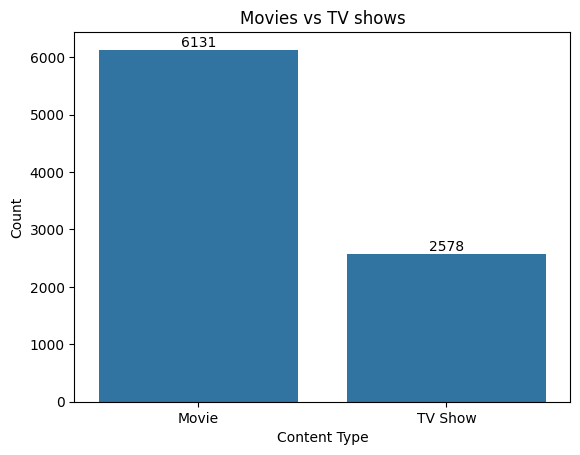

<Figure size 640x480 with 0 Axes>

In [21]:
plt.Figure(figsize=(6,4))
ax = sns.countplot(x= 'type', data= df)

plt.title("Movies vs TV shows")
plt.xlabel("Content Type")
plt.ylabel("Count")

ax.bar_label(ax.containers[0])
plt.show()
plt.savefig("Movies vs TV shows.png")

# 📌 Insight
- Netflix contains more Movies than TV Shows.
- However, TV Shows are increasing rapidly in recent years.
# ✅ Recommendation
- Netflix should continue investing in original TV series
because long-form content improves user retention.

# 📌 Analysis 2 — Content Added Over Time

In [22]:
# Count content added each year.
yearly_content = df['year'].value_counts().sort_index()
yearly_content

year
2008       2
2009       2
2010       1
2011      13
2012       3
2013      10
2014      23
2015      73
2016     418
2017    1164
2018    1625
2019    1999
2020    1878
2021    1498
Name: count, dtype: int64

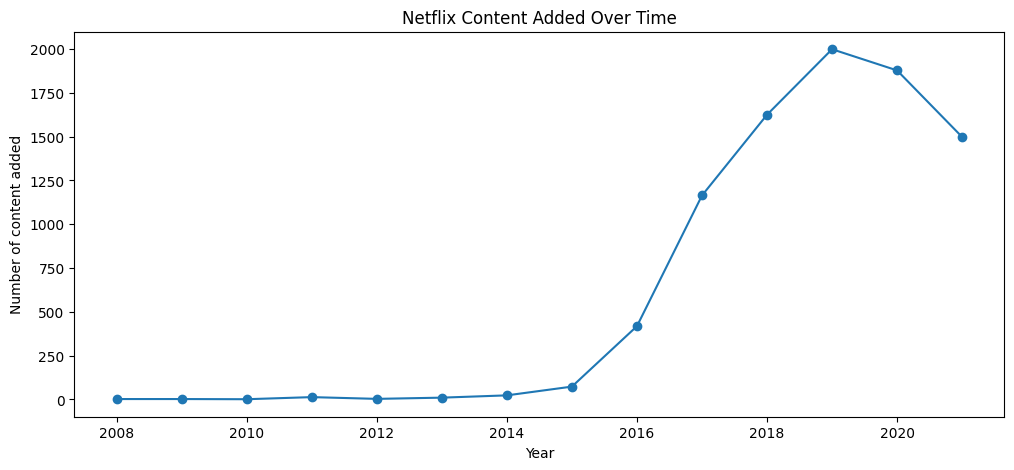

<Figure size 640x480 with 0 Axes>

In [32]:
# Line plot
plt.figure(figsize=(12,5))
yearly_content.plot(kind = 'line', marker = "o")

plt.title("Netflix Content Added Over Time")
plt.xlabel("Year")
plt.ylabel("Number of content added")

plt.show()
plt.savefig("Netflix Content Added Over Time.png")

# 📌 Insight
Netflix experienced massive growth after 2016.
This indicates aggressive global content expansion.
# ✅ Recommendation
Netflix should continue region-specific content production
to maintain subscriber growth.

# 📌 Analysis 3 — Top 10 Countries

In [24]:
# Top Countries
top_countries = df['country'].value_counts().head(10) 
top_countries

country
United States     2778
India              971
unknown            827
United Kingdom     403
Japan              241
South Korea        195
Canada             173
Spain              141
France             122
Mexico             110
Name: count, dtype: int64

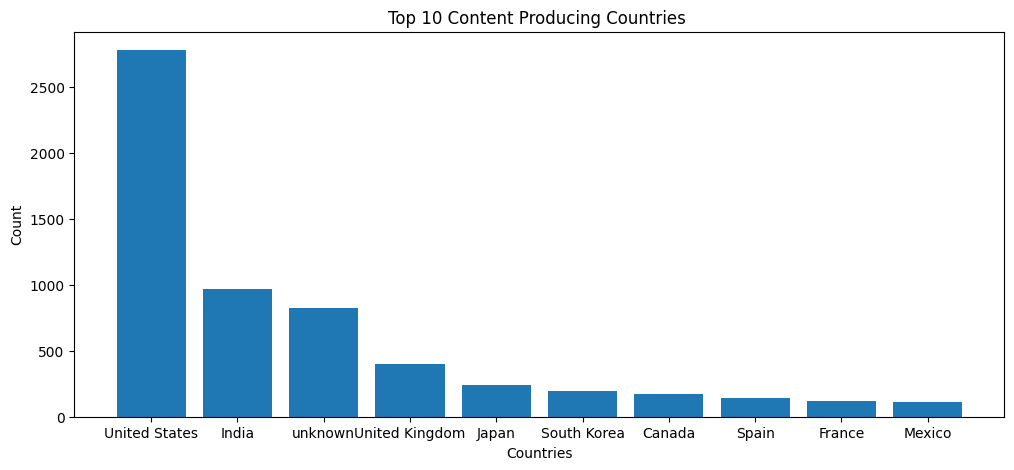

<Figure size 640x480 with 0 Axes>

In [33]:
plt.figure(figsize=(12,5))
plt.bar(top_countries.index,top_countries.values)

plt.title("Top 10 Content Producing Countries ")
plt.xlabel('Countries')
plt.ylabel("Count")

plt.show()
plt.savefig("Top 10 Content Producing Countries.png")

# 📌 Insight
USA dominates Netflix content production.
Asian and African countries have lower representation.
# ✅ Recommendation
Netflix can expand audience reach by increasing
local-language content from emerging markets.

# 📌 Analysis 4 — Most Popular Genres

In [26]:
top_generes = df['primary_genre'].value_counts().head(10)
top_generes

primary_genre
Dramas                      1600
Comedies                    1210
Action & Adventure           859
Documentaries                829
International TV Shows       761
Children & Family Movies     605
Crime TV Shows               391
Kids' TV                     373
Stand-Up Comedy              334
Horror Movies                275
Name: count, dtype: int64

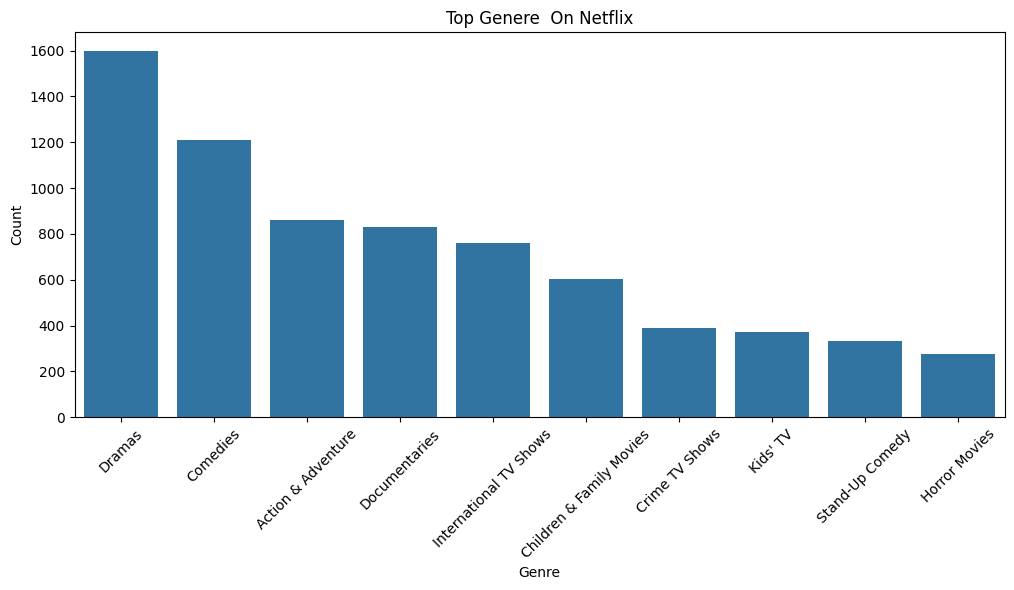

<Figure size 640x480 with 0 Axes>

In [34]:
plt.figure(figsize=(12,5))
sns.barplot(x = top_generes.index, y = top_generes.values )

plt.title("Top Genere  On Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation = 45)

plt.show()
plt.savefig("Top Genere  On Netflix.png")

# 📌 Insight
Drama and International genres dominate Netflix.
This shows strong audience interest in emotional
and globally relatable storytelling.
# ✅ Recommendation
Netflix should continue investing in multilingual
and culturally diverse content.

# 📌 Analysis 5 — Rating Distribution

In [28]:
df['rating'].value_counts()

rating
TV-MA       3187
TV-14       2133
TV-PG        838
R            799
PG-13        490
TV-Y7        330
TV-Y         300
PG           287
TV-G         212
NR            78
G             41
TV-Y7-FV       5
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

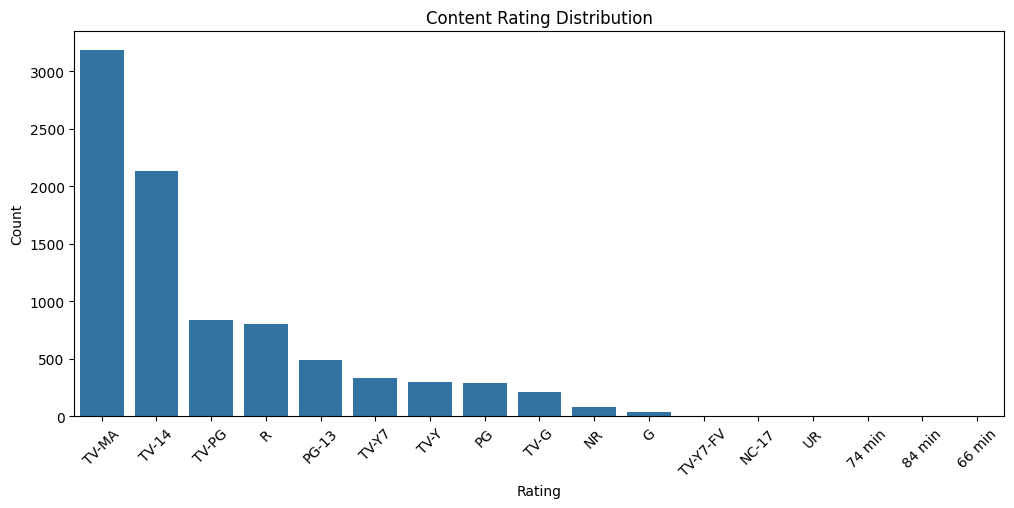

<Figure size 640x480 with 0 Axes>

In [35]:
# Rating plot

plt.figure(figsize=(12,5))

sns.countplot(x='rating',
              data=df,
              order=df['rating'].value_counts().index)

plt.title('Content Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()
plt.savefig("Content Rating Distribution.png")

# 📌 Insight
TV-MA and TV-14 dominate the platform.
Netflix mainly targets adult and teenage audiences.
# ✅ Recommendation
Netflix can increase family-friendly content
to attract wider audience segments.

# 📌 Analysis 6 — Movies vs TV Shows Trend Over Years

In [30]:
content_trend = df.groupby(['year', 'type']).size().unstack()
content_trend

type,Movie,TV Show
year,,
2008,1.0,1.0
2009,2.0,NaN
2010,1.0,NaN
2011,13.0,NaN
2012,3.0,NaN
2013,6.0,4.0
2014,19.0,4.0
2015,56.0,17.0
2016,253.0,165.0


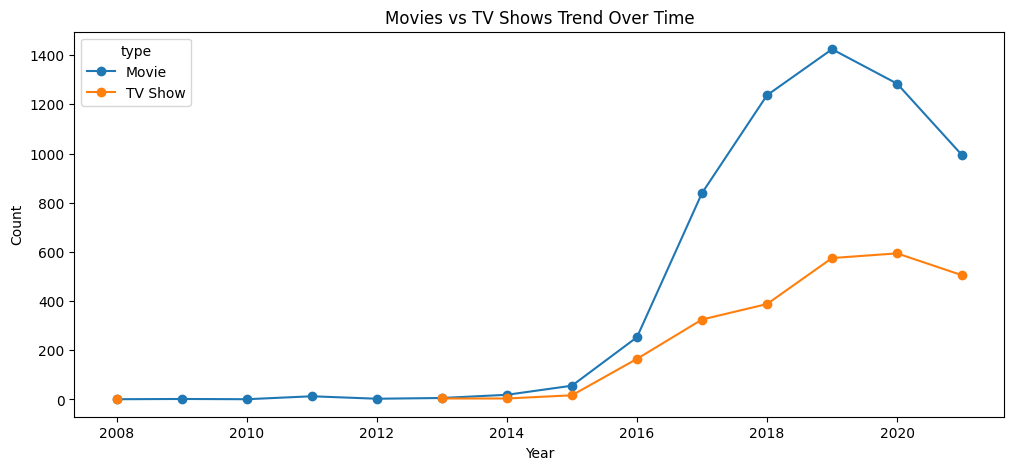

<Figure size 640x480 with 0 Axes>

In [36]:
content_trend.plot(figsize=(12, 5),marker = "o")

plt.title("Movies vs TV Shows Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Count")

plt.show()
plt.savefig("Movies vs TV Shows Trend Over Time.png")

# 📌 Insight
TV Shows are growing faster than Movies.
Streaming platforms are shifting toward binge-watch culture.
# ✅ Recommendation
Netflix should prioritize high-retention episodic content.

# 📌 Final Business Insights
# ✅ Insight 1 — Content Strategy Shift

Netflix is increasingly investing in TV Shows. This reflects changing audience behavior toward binge-watching.

# Recommendation:

Increase investment in high-quality original series.

# ✅ Insight 2 — Global Expansion Opportunity

Most content originates from the USA. Some regions remain underrepresented.

# Recommendation:

Expand local productions in Asia, Africa, and the Middle East.

# ✅ Insight 3 — Genre Demand

Drama and International content dominate platform engagement.

# Recommendation:

Invest more in multilingual storytelling.

# ✅ Insight 4 — Content Aging Problem

Older content may reduce user engagement.

# Recommendation:

Regularly refresh library using viewer analytics.

# ✅ Insight 5 — Audience Targeting Imbalance

Netflix contains high amounts of adult-focused content.

# Recommendation:

Increase children and family-oriented content.

# 📌 Final Conclusion

In this project, we:

- cleaned raw Netflix data
- handled missing values
- engineered useful features
- created visualizations
- generated business insights
- provided strategic recommendations

This project demonstrates practical Data Analytics skills used in real-world industry environments.

# 🚀 Skills Demonstrated

- ✅ Data Cleaning 
- ✅ Missing Value Handling  
- ✅ Feature Engineering 
- ✅ Exploratory Data Analysis  
- ✅ Data Visualization 
- ✅ Business Analytics 
- ✅ Insight Generation 
- ✅ Strategic Thinking